# TASK 4 - Hand Gesture Recognition using CNN

Saving handgestures.zip to handgestures (2).zip
Dataset extracted successfully!
Folders inside dataset:
['palm', 'fist_moved', 'fist', 'I']
Found 320 images belonging to 4 classes.
Found 80 images belonging to 4 classes.
Class Labels:
{'I': 0, 'fist': 1, 'fist_moved': 2, 'palm': 3}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.4969 - loss: 1.2113 - val_accuracy: 0.6750 - val_loss: 0.9103
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8313 - loss: 0.5243 - val_accuracy: 0.8500 - val_loss: 0.4592
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9219 - loss: 0.1971 - val_accuracy: 0.9250 - val_loss: 0.3233


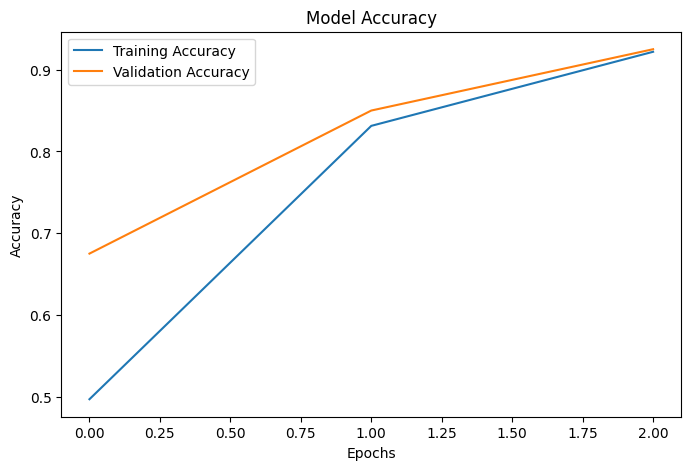

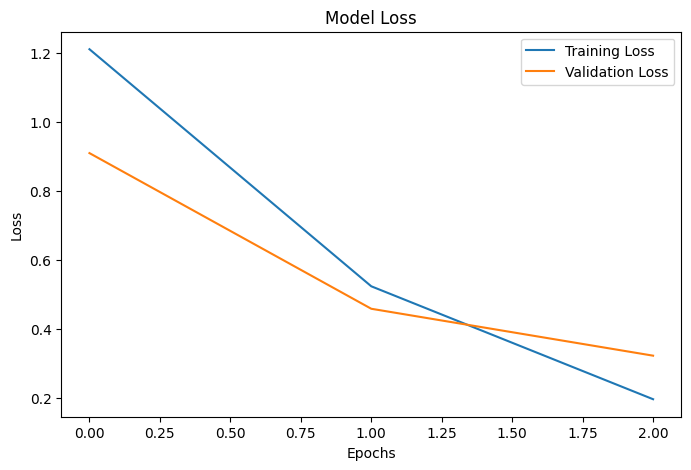

Model saved successfully!


Saving frame_00_01_0190.png to frame_00_01_0190.png
Saving frame_00_02_0200.png to frame_00_02_0200.png
Saving frame_00_03_0092.png to frame_00_03_0092.png

Image: frame_00_01_0190.png
Predicted Gesture: palm
Confidence: 99.88%


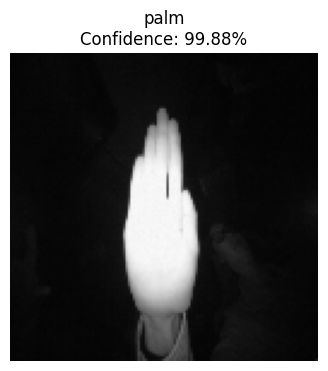


Image: frame_00_02_0200.png
Predicted Gesture: I
Confidence: 99.95%


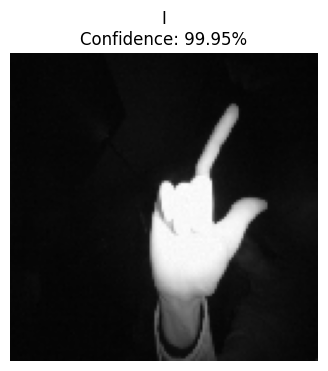


Image: frame_00_03_0092.png
Predicted Gesture: fist
Confidence: 100.00%


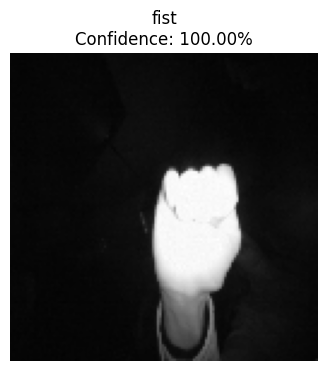

In [5]:
# Hand Gesture Recognition using CNN

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from google.colab import files

# Upload hand gesture dataset zip file
uploaded = files.upload()

# Extract zip file
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("hand_gesture_dataset")

print("Dataset extracted successfully!")

# Dataset path
dataset_path = "hand_gesture_dataset"

# Check folders
print("Folders inside dataset:")
print(os.listdir(dataset_path))

# Image preprocessing
img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Class names
print("Class Labels:")
print(train_data.class_indices)

# Build CNN model
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

# Plot accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Save model
model.save("hand_gesture_model.h5")
print("Model saved successfully!")

# Test with a new image
# Test multiple gesture images

from tensorflow.keras.preprocessing import image

uploaded_test = files.upload()

class_labels = list(train_data.class_indices.keys())

for test_img_name in uploaded_test.keys():

    test_img = image.load_img(
        test_img_name,
        target_size=(img_size, img_size)
    )

    test_img_array = image.img_to_array(test_img)
    test_img_array = test_img_array / 255.0
    test_img_array = np.expand_dims(test_img_array, axis=0)

    prediction = model.predict(test_img_array, verbose=0)

    predicted_class_index = np.argmax(prediction)

    predicted_class = class_labels[predicted_class_index]

    confidence = np.max(prediction) * 100

    print(f"\nImage: {test_img_name}")
    print(f"Predicted Gesture: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

    plt.figure(figsize=(4,4))
    plt.imshow(test_img)
    plt.title(
        f"{predicted_class}\nConfidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()